In [ ]:

import os
import torch
import numpy as np
import rasterio
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
from albumentations.pytorch import ToTensorV2
import albumentations as A
from tqdm import tqdm
from PIL import Image
import seaborn as sns

# Importing my UNET model
from UNETModel import UNET
from ImagePreparation import HabitatDataset

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
NUM_CLASSES = 7

# Color map for visualization (7 habitat classes)
COLOR_MAP = np.array([
    [0, 0, 0],          # 0 Background - black
    [133, 165, 116],    # 1 Seagrass - green
    [241, 147, 112],    # 2 Coral - red
    [110, 140, 64],     # 3 Macroalgae - yellow
    [225, 216, 185],    # 4 Sand - tan/beige
    [126, 93, 70],      # 5 Land - brown
    [141, 190, 255],    # 6 Ocean - blue
], dtype=np.uint8)

CLASS_NAMES = [
    'Background', 'Seagrass', 'Coral', 'Macroalgae', 
    'Sand', 'Land', 'Ocean'
]

In [ ]:
def load_model(checkpoint_path):
    """Load the trained U-Net model."""
    model = UNET(in_channels=8, out_channels=7).to(device)
    model.load_state_dict(torch.load(checkpoint_path, map_location=device))
    model.eval()
    print(f"Model loaded from {checkpoint_path}")
    return model


def predict_and_save(model, input_folder, output_folder, band_stats=None):
    os.makedirs(output_folder, exist_ok=True)
    os.makedirs(os.path.join(output_folder, 'tiff'), exist_ok=True)
    os.makedirs(os.path.join(output_folder, 'png'), exist_ok=True)
    
    files = sorted([f for f in os.listdir(input_folder) if f.endswith('.tif')])
    
    # Get normalization stats if not provided
    if band_stats is None:
        print("Computing normalization statistics...")
        dataset = HabitatDataset(
            img_dir=input_folder,
            mask_dir=input_folder,
            mode='patch',
            patch_size=256
        )
        band_stats = dataset.band_stats
    
    print(f"\nGenerating predictions for {len(files)} images...")
    
    for name in tqdm(files, desc="Predicting"):
        image_path = os.path.join(input_folder, name)
        
        # Load image
        with rasterio.open(image_path) as src:
            img = src.read().astype("float32")
            profile = src.profile
        
        # Normalize using dataset statistics
        mean = band_stats['mean'].reshape(-1, 1, 1)
        std = band_stats['std'].reshape(-1, 1, 1)
        img = (img - mean) / (std + 1e-8)
        
        # Convert to tensor
        img_tensor = torch.from_numpy(img).unsqueeze(0).to(device)
        
        # Predict
        with torch.no_grad():
            logits = model(img_tensor)
            pred = torch.argmax(logits, dim=1).squeeze().cpu().numpy()
        
        pred_uint8 = pred.astype(np.uint8)
        
        # Save TIFF
        profile.update(count=1, dtype="uint8")
        tiff_path = os.path.join(output_folder, 'tiff', name)
        
        with rasterio.open(tiff_path, "w", **profile) as dst:
            dst.write(pred_uint8, 1)
        
        # Save colored PNG
        color_img = COLOR_MAP[pred_uint8]  # (H, W, 3)
        png_path = os.path.join(output_folder, 'png', name.replace(".tif", ".png"))
        Image.fromarray(color_img).save(png_path)
    
    print(f"\nPredictions saved to:")
    print(f"  - TIFF: {os.path.join(output_folder, 'tiff')}")
    print(f"  - PNG:  {os.path.join(output_folder, 'png')}")

In [ ]:
def evaluate_accuracy(gt_folder, pred_folder, class_names=CLASS_NAMES):
    gt_files = sorted([f for f in os.listdir(gt_folder) if f.endswith('.tif')])
    
    all_gt = []
    all_pred = []
    
    print(f"\nEvaluating {len(gt_files)} images...")
    
    for file in tqdm(gt_files, desc="Loading masks"):
        gt_path = os.path.join(gt_folder, file)
        pred_path = os.path.join(pred_folder, 'tiff', file)
        
        if not os.path.exists(pred_path):
            print(f"Warning: Prediction not found for {file}")
            continue
        
        # Load ground truth
        with rasterio.open(gt_path) as src:
            gt = src.read(1).astype(np.int64)
        
        # Load prediction
        with rasterio.open(pred_path) as src:
            pred = src.read(1).astype(np.int64)
        
        all_gt.append(gt.flatten())
        all_pred.append(pred.flatten())
    
    # Concatenate all pixels
    all_gt = np.concatenate(all_gt)
    all_pred = np.concatenate(all_pred)
    
    # Compute confusion matrix
    cm = confusion_matrix(all_gt, all_pred, labels=list(range(NUM_CLASSES)))
    
    # Compute metrics
    TP = np.diag(cm)
    FP = cm.sum(axis=0) - TP
    FN = cm.sum(axis=1) - TP
    TN = cm.sum() - (FP + FN + TP)
    
    # Overall accuracy
    overall_acc = TP.sum() / cm.sum()
    
    # Per-class metrics
    precision = TP / (TP + FP + 1e-10)
    recall = TP / (TP + FN + 1e-10)
    f1_score = 2 * (precision * recall) / (precision + recall + 1e-10)
    iou = TP / (TP + FP + FN + 1e-10)
    
    # Print results
    print("\n" + "="*70)
    print("EVALUATION RESULTS")
    print("="*70)
    
    print(f"\nOverall Pixel Accuracy: {overall_acc:.4f} ({overall_acc*100:.2f}%)")
    print(f"Mean IoU: {np.mean(iou):.4f}")
    print(f"Mean F1-Score: {np.mean(f1_score):.4f}")
    
    print("\nPer-Class Metrics:")
    print("-"*70)
    print(f"{'Class':<15} {'Precision':<12} {'Recall':<12} {'F1-Score':<12} {'IoU':<12}")
    print("-"*70)
    
    for i in range(NUM_CLASSES):
        print(f"{class_names[i]:<15} {precision[i]:<12.4f} {recall[i]:<12.4f} "
              f"{f1_score[i]:<12.4f} {iou[i]:<12.4f}")
    
    print("-"*70)
    
    # Plot confusion matrix
    plot_confusion_matrix(cm, class_names)
    
    # Plot per-class metrics
    plot_class_metrics(precision, recall, f1_score, iou, class_names)
    
    # Classification report
    print("\nDetailed Classification Report:")
    print(classification_report(all_gt, all_pred, target_names=class_names, digits=4))
    
    # Return metrics
    metrics = {
        'confusion_matrix': cm,
        'overall_accuracy': overall_acc,
        'precision': precision,
        'recall': recall,
        'f1_score': f1_score,
        'iou': iou,
        'mean_iou': np.mean(iou)
    }
    
    return metrics

Loading model...
Model loaded from unet_final_model.pth

GENERATING PREDICTIONS
Computing normalization statistics...
Computing band statistics for normalization...
Band means: [333.43372 312.73245 366.93146 276.62698 170.5221  256.37604 304.4557
 236.65265]
Band stds: [106.48118  127.770424 205.53941  204.27007  144.62096  251.54451
 359.8682   283.61325 ]

Generating predictions for 9 images...


Predicting: 100%|██████████| 9/9 [01:09<00:00,  7.71s/it]



Predictions saved to:
  - TIFF: predictions\tiff
  - PNG:  predictions\png

EVALUATING MODEL PERFORMANCE

Evaluating 9 images...


Loading masks:   0%|          | 0/9 [00:00<?, ?it/s]c:\Users\Peter Chapman\anaconda3\Lib\site-packages\rasterio\__init__.py:368: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)
Loading masks: 100%|██████████| 9/9 [00:00<00:00, 20.01it/s]



EVALUATION RESULTS

Overall Pixel Accuracy: 0.8462 (84.62%)
Mean IoU: 0.6415
Mean F1-Score: 0.7519

Per-Class Metrics:
----------------------------------------------------------------------
Class           Precision    Recall       F1-Score     IoU         
----------------------------------------------------------------------
Background      0.9563       0.9659       0.9611       0.9251      
Seagrass        0.3092       0.7719       0.4415       0.2833      
Coral           0.5079       0.6893       0.5849       0.4133      
Macroalgae      0.7894       0.6711       0.7255       0.5692      
Sand            0.6879       0.6018       0.6420       0.4727      
Land            0.9941       0.9653       0.9795       0.9598      
Ocean           0.9941       0.8712       0.9286       0.8668      
----------------------------------------------------------------------

Confusion matrix saved to: confusion_matrix.png


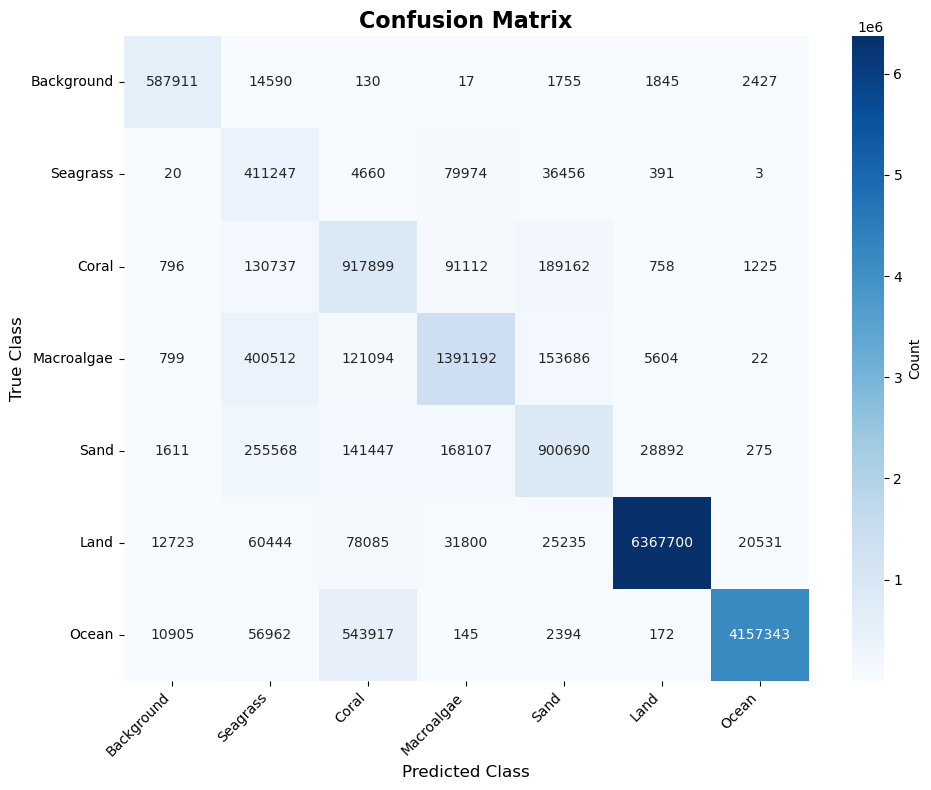

Class metrics plot saved to: class_metrics.png


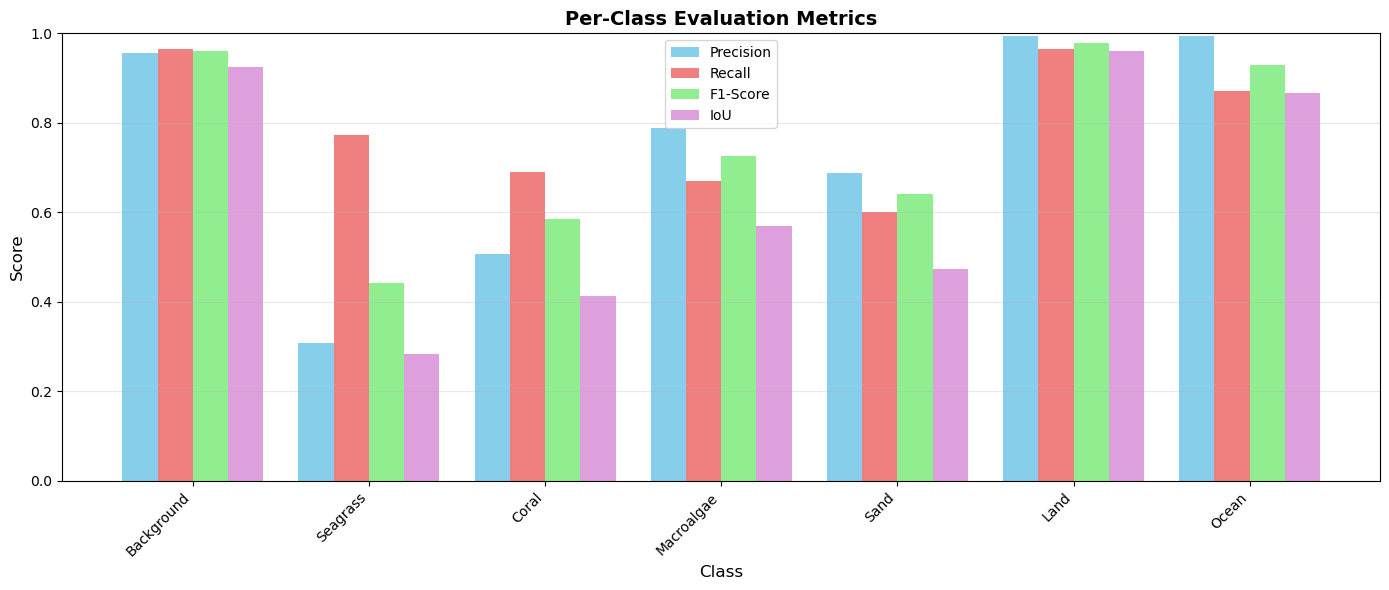


Detailed Classification Report:
              precision    recall  f1-score   support

  Background     0.9563    0.9659    0.9611    608675
    Seagrass     0.3092    0.7719    0.4415    532751
       Coral     0.5079    0.6893    0.5849   1331689
  Macroalgae     0.7894    0.6711    0.7255   2072909
        Sand     0.6879    0.6018    0.6420   1496590
        Land     0.9941    0.9653    0.9795   6596518
       Ocean     0.9941    0.8712    0.9286   4771838

    accuracy                         0.8462  17410970
   macro avg     0.7484    0.7909    0.7519  17410970
weighted avg     0.8840    0.8462    0.8590  17410970


VISUALIZING PREDICTIONS


c:\Users\Peter Chapman\anaconda3\Lib\site-packages\rasterio\__init__.py:368: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)


Prediction visualization saved to: predictions_visualization.png


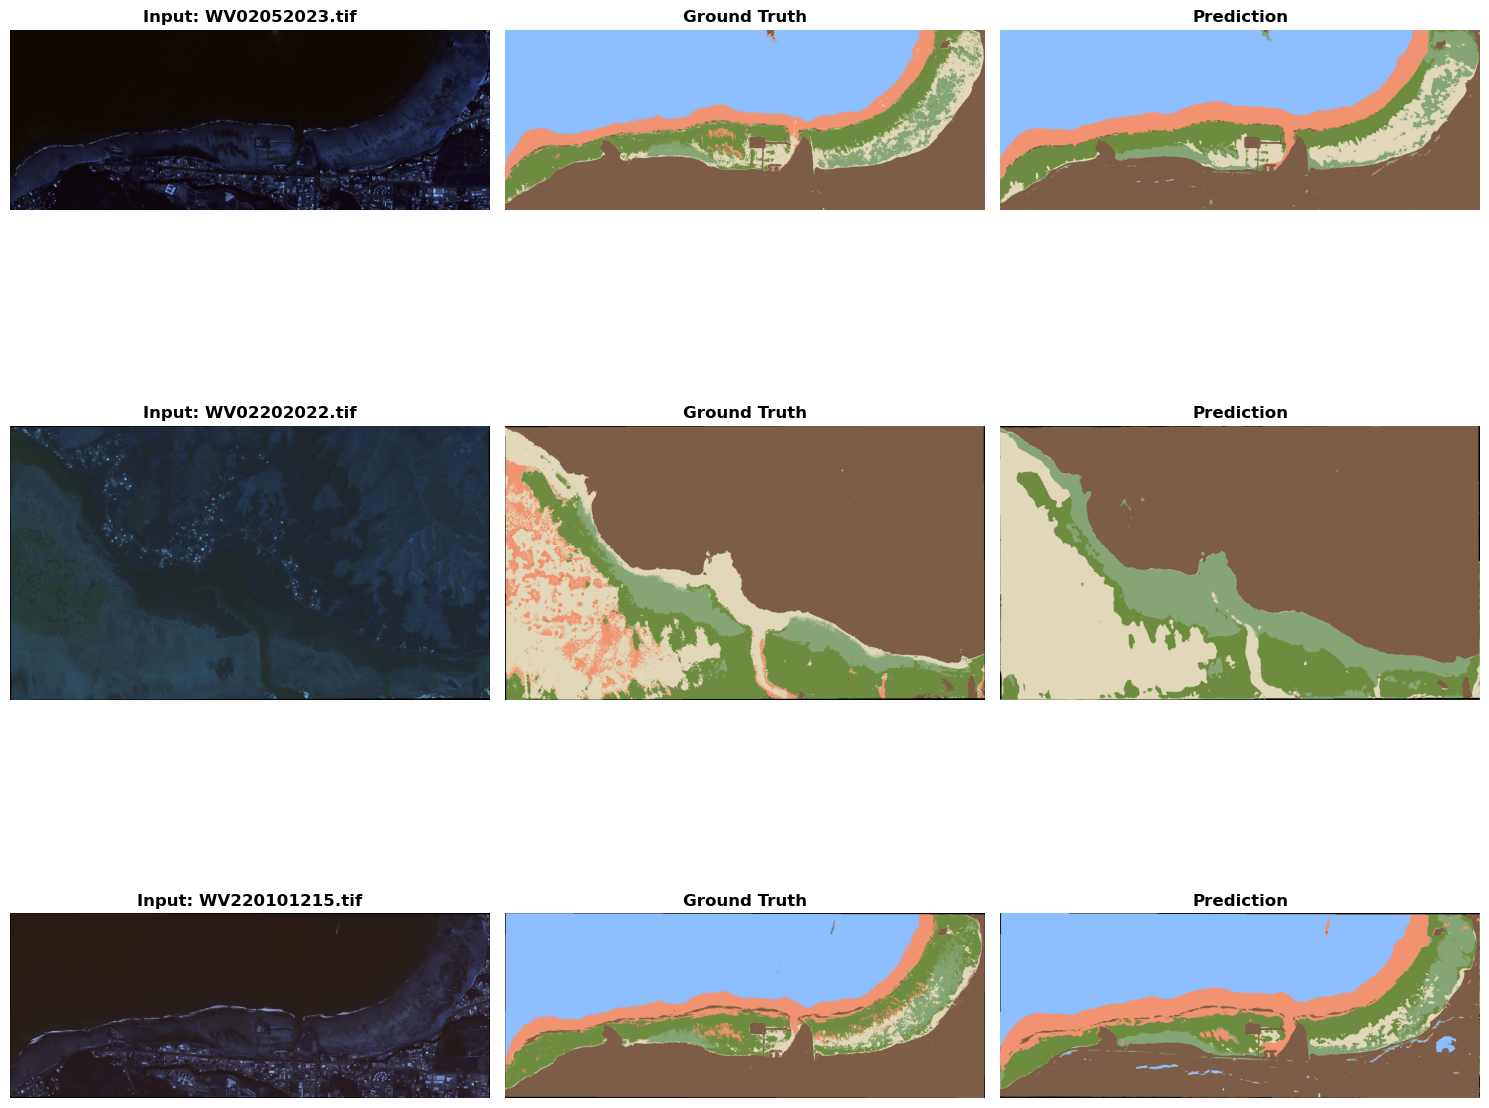


EVALUATION COMPLETE!

Results saved:
  - Predictions: predictions/
  - Confusion Matrix: confusion_matrix.png
  - Class Metrics: class_metrics.png
  - Visualizations: predictions_visualization.png


In [ ]:
def plot_confusion_matrix(cm, class_names):
    """Plot and save confusion matrix."""
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names,
                cbar_kws={'label': 'Count'})
    plt.title('Confusion Matrix', fontsize=16, fontweight='bold')
    plt.xlabel('Predicted Class', fontsize=12)
    plt.ylabel('True Class', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
    print("\nConfusion matrix saved to: confusion_matrix.png")
    plt.show()


def plot_class_metrics(precision, recall, f1_score, iou, class_names):
    """Plot per-class metrics."""
    x = np.arange(len(class_names))
    width = 0.2
    
    fig, ax = plt.subplots(figsize=(14, 6))
    
    ax.bar(x - 1.5*width, precision, width, label='Precision', color='skyblue')
    ax.bar(x - 0.5*width, recall, width, label='Recall', color='lightcoral')
    ax.bar(x + 0.5*width, f1_score, width, label='F1-Score', color='lightgreen')
    ax.bar(x + 1.5*width, iou, width, label='IoU', color='plum')
    
    ax.set_xlabel('Class', fontsize=12)
    ax.set_ylabel('Score', fontsize=12)
    ax.set_title('Per-Class Evaluation Metrics', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(class_names, rotation=45, ha='right')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    ax.set_ylim([0, 1.0])
    
    plt.tight_layout()
    plt.savefig('class_metrics.png', dpi=300, bbox_inches='tight')
    print("Class metrics plot saved to: class_metrics.png")
    plt.show()


def visualize_predictions(input_folder, gt_folder, pred_folder, num_samples=3):
    files = sorted([f for f in os.listdir(input_folder) if f.endswith('.tif')])[:num_samples]
    
    fig, axes = plt.subplots(num_samples, 3, figsize=(15, 5*num_samples))
    if num_samples == 1:
        axes = axes.reshape(1, -1)
    
    for idx, file in enumerate(files):
        # Load input (display first 3 bands as RGB)
        with rasterio.open(os.path.join(input_folder, file)) as src:
            img = src.read([1, 2, 3]).astype('float32')
            img = np.transpose(img, (1, 2, 0))
            img = (img - img.min()) / (img.max() - img.min() + 1e-10)
        
        # Load ground truth
        with rasterio.open(os.path.join(gt_folder, file)) as src:
            gt = src.read(1)
        
        # Load prediction
        pred_file = os.path.join(pred_folder, 'tiff', file)
        with rasterio.open(pred_file) as src:
            pred = src.read(1)
        
        # Plot
        axes[idx, 0].imshow(img)
        axes[idx, 0].set_title(f'Input: {file}', fontweight='bold')
        axes[idx, 0].axis('off')
        
        axes[idx, 1].imshow(COLOR_MAP[gt])
        axes[idx, 1].set_title('Ground Truth', fontweight='bold')
        axes[idx, 1].axis('off')
        
        axes[idx, 2].imshow(COLOR_MAP[pred])
        axes[idx, 2].set_title('Prediction', fontweight='bold')
        axes[idx, 2].axis('off')
    
    plt.tight_layout()
    plt.savefig('predictions_visualization.png', dpi=300, bbox_inches='tight')
    print("Prediction visualization saved to: predictions_visualization.png")
    plt.show()


if __name__ == "__main__":
    # Configuration
    MODEL_PATH = "unet_final_model.pth"
    INPUT_IMAGES = r'C:\Users\Peter Chapman\Personal_Research_Projects\benthic-habitat-segmentation-ML\Project 4 Dataset\Project 4 Dataset\raw_labeled_data\images'
    OUTPUT_PREDS = "predictions"
    GT_MASKS = r'C:\Users\Peter Chapman\Personal_Research_Projects\benthic-habitat-segmentation-ML\Project 4 Dataset\Project 4 Dataset\raw_labeled_data\annotations'
    
    # Load model
    print("Loading model...")
    model = load_model(MODEL_PATH)
    
    # Generate predictions
    print("\n" + "="*70)
    print("GENERATING PREDICTIONS")
    print("="*70)
    predict_and_save(model, INPUT_IMAGES, OUTPUT_PREDS)
    
    # Evaluate accuracy
    print("\n" + "="*70)
    print("EVALUATING MODEL PERFORMANCE")
    print("="*70)
    metrics = evaluate_accuracy(GT_MASKS, OUTPUT_PREDS)
    
    # Visualize some predictions
    print("\n" + "="*70)
    print("VISUALIZING PREDICTIONS")
    print("="*70)
    visualize_predictions(INPUT_IMAGES, GT_MASKS, OUTPUT_PREDS, num_samples=3)
    
    print("\n" + "="*70)
    print("EVALUATION COMPLETE!")
    print("="*70)
    print(f"\nResults saved:")
    print(f"  - Predictions: {OUTPUT_PREDS}/")
    print(f"  - Confusion Matrix: confusion_matrix.png")
    print(f"  - Class Metrics: class_metrics.png")
    print(f"  - Visualizations: predictions_visualization.png")